# Kratos MCP Server — lid-driven cavity (CFD) walkthrough

This notebook drives the **real** `kratos-mcp` server over stdio to solve the
classic **lid-driven cavity** benchmark: a unit square of fluid whose top wall
slides at u = 1 m/s, driving a single recirculating vortex. It introspects the
fluid solver, runs the shipped verified example, post-processes the velocity
field, and renders an inline PNG and an animated GIF — no ParaView needed.

Pairs with the `kratos://examples/lid-driven-cavity` resource and the
`docs/tutorials/lid-driven-cavity.md` tutorial. Every output is from a live run
against a compiled Kratos 10.4 build (FluidDynamicsApplication). The `viz`
extra (`uv sync --extra viz`) is needed for the render/animate cells.

In [1]:
import asyncio
import base64
import json
import shutil
import sys
import tempfile
from pathlib import Path
from contextlib import AsyncExitStack

from IPython.display import Image as IPImage, Markdown, display

from mcp import ClientSession, StdioServerParameters
from mcp.client.stdio import stdio_client


def _preview(value, limit=4000):
    text = value if isinstance(value, str) else json.dumps(value, indent=2, default=str)
    if len(text) > limit:
        text = text[: limit] + f"\n... [truncated, {len(text)} chars total]"
    print(text)


async def call(tool_name, **kwargs):
    # Call an MCP tool, print its JSON result, display any inline images,
    # and return the parsed value for use in later cells.
    result = await session.call_tool(tool_name, kwargs)
    value = None
    for block in result.content:
        if block.type == "text":
            try:
                value = json.loads(block.text)
            except json.JSONDecodeError:
                value = block.text
        elif block.type == "image":
            display(IPImage(data=base64.b64decode(block.data), format=block.mimeType.split("/")[-1]))
    _preview(value)
    return value


async def read_resource(uri):
    result = await session.read_resource(uri)
    return result.contents[0].text


async def get_prompt(name, **kwargs):
    result = await session.get_prompt(name, kwargs)
    return result.messages[0].content.text

## Connect to the server\n\nThe server's stdio pipes are managed by anyio context managers whose cancel scopes are tied to the asyncio Task that opened them. Every Jupyter cell runs its top-level `await` in a *new* Task, so we run the whole connect → disconnect lifecycle inside one persistent background task kept alive on an `asyncio.Event`, and only *signal* it to close.

In [2]:
session = None
_stop_event = asyncio.Event()
_ready_event = asyncio.Event()


async def _server_lifecycle():
    global session
    async with AsyncExitStack() as stack:
        params = StdioServerParameters(command=sys.executable, args=["-m", "kratos_mcp.server"])
        read, write = await stack.enter_async_context(stdio_client(params))
        session = await stack.enter_async_context(ClientSession(read, write))
        await session.initialize()
        _ready_event.set()
        await _stop_event.wait()  # keeps this task (and the session) alive


_server_task = asyncio.create_task(_server_lifecycle())
await _ready_event.wait()

tools = await session.list_tools()
resources = await session.list_resources()
prompts = await session.list_prompts()
print(f"{len(tools.tools)} tools, {len(resources.resources)} resources, "
      f"{len(prompts.prompts)} prompts")
print("resources:", [str(r.uri) for r in resources.resources])

40 tools, 13 resources, 5 prompts
resources: ['kratos://docs/mdpa-format', 'kratos://docs/project-parameters', 'kratos://docs/materials', 'kratos://examples/cantilever', 'kratos://examples/thermal-bar', 'kratos://examples/naca-airfoil', 'kratos://examples/lid-driven-cavity', 'kratos://examples/plasticity-cube', 'kratos://examples/multistage-load-steps', 'kratos://examples/channel-flow', 'kratos://examples/modal-box', 'kratos://examples/dynamic-cantilever', 'kratos://examples/potential-flow']


## 1. Introspect the fluid solver

What incompressible-flow solvers does this build expose, and what does the monolithic (VMS) solver accept?

In [3]:
await call("kratos_list_solvers", analysis_type="fluid")

{
  "fluid": {
    "solver_types": {
      "Monolithic": "KratosMultiphysics.FluidDynamicsApplication.navier_stokes_monolithic_solver",
      "FractionalStep": "KratosMultiphysics.FluidDynamicsApplication.navier_stokes_solver_fractionalstep",
      "Embedded": "KratosMultiphysics.FluidDynamicsApplication.navier_stokes_embedded_solver",
      "CompressibleExplicit": "KratosMultiphysics.FluidDynamicsApplication.navier_stokes_compressible_explicit_solver",
      "LowMach": "KratosMultiphysics.FluidDynamicsApplication.navier_stokes_low_mach_solver"
    },
    "all_solver_modules_in_source": [
      "adjoint_fluid_solver",
      "adjoint_monolithic_solver",
      "fluid_solver",
      "navier_stokes_ale_fluid_solver",
      "navier_stokes_compressible_explicit_solver",
      "navier_stokes_embedded_solver",
      "navier_stokes_low_mach_solver",
      "navier_stokes_monolithic_iga_solver",
      "navier_stokes_monolithic_solver",
      "navier_stokes_two_fluids_solver",
      "trilinos_adjo

{'fluid': {'solver_types': {'Monolithic': 'KratosMultiphysics.FluidDynamicsApplication.navier_stokes_monolithic_solver',
   'FractionalStep': 'KratosMultiphysics.FluidDynamicsApplication.navier_stokes_solver_fractionalstep',
   'Embedded': 'KratosMultiphysics.FluidDynamicsApplication.navier_stokes_embedded_solver',
   'CompressibleExplicit': 'KratosMultiphysics.FluidDynamicsApplication.navier_stokes_compressible_explicit_solver',
   'LowMach': 'KratosMultiphysics.FluidDynamicsApplication.navier_stokes_low_mach_solver'},
  'all_solver_modules_in_source': ['adjoint_fluid_solver',
   'adjoint_monolithic_solver',
   'fluid_solver',
   'navier_stokes_ale_fluid_solver',
   'navier_stokes_compressible_explicit_solver',
   'navier_stokes_embedded_solver',
   'navier_stokes_low_mach_solver',
   'navier_stokes_monolithic_iga_solver',
   'navier_stokes_monolithic_solver',
   'navier_stokes_two_fluids_solver',
   'trilinos_adjoint_monolithic_solver',
   'trilinos_navier_stokes_embedded_solver',
  

In [4]:
defaults = await call("kratos_get_solver_defaults", analysis_type="fluid", solver_type="Monolithic")

{
  "absolute_pressure_tolerance": 1e-05,
  "absolute_velocity_tolerance": 1e-05,
  "alpha": -0.3,
  "analysis_type": "non_linear",
  "assign_neighbour_elements_to_conditions": true,
  "compute_reactions": false,
  "consider_periodic_conditions": false,
  "domain_size": -1,
  "echo_level": 0,
  "enforce_element_and_conditions_replacement": true,
  "formulation": {
    "element_type": "vms"
  },
  "linear_solver_settings": {
    "solver_type": "amgcl"
  },
  "material_import_settings": {
    "materials_filename": ""
  },
  "maximum_iterations": 10,
  "model_import_settings": {
    "input_filename": "unknown_name",
    "input_type": "mdpa",
    "reorder": false
  },
  "model_part_name": "FluidModelPart",
  "move_mesh_flag": false,
  "move_mesh_strategy": 0,
  "no_skin_parts": [
    ""
  ],
  "periodic": "periodic",
  "pressure_relaxation": 0.9,
  "reform_dofs_at_each_step": true,
  "relative_pressure_tolerance": 0.001,
  "relative_velocity_tolerance": 0.001,
  "skin_parts": [
    ""
  ],

## 2. The lid-driven cavity example

Read the worked-example resource (files + verified recirculation result), then copy the real files to a working directory.

In [5]:
print(await read_resource("kratos://examples/lid-driven-cavity"))

# Worked example: lid-driven cavity (incompressible flow, monolithic)

The classic CFD benchmark. A unit square filled with fluid; the top wall
("lid") slides at u = 1 m/s while the other three walls are no-slip. The
shear dragged in by the lid drives a single large recirculating vortex. The
files below are real files on disk (src/kratos_mcp/examples/lid_driven_cavity/),
read verbatim -- not rendered from templates at request time.

The mesh is a coarse 10x10 unit square of triangles (121 nodes) generated by
this server's own mdpa_create_structured_mesh; a single corner node pins the
pressure (otherwise it is only defined up to a constant). Density 100 and
dynamic viscosity 1 give a chord Reynolds number Re = rho*U*L/mu = 100 -- the
mildest Ghia benchmark, one steady primary vortex, no secondary corner
eddies.

## mesh.mdpa

```
Begin ModelPartData
End ModelPartData

Begin Properties 1
End Properties

Begin Nodes
    1 0 0 0
    2 0.1 0 0
    3 0.2 0 0
    4 0.3 0 0
    5 0.4 0 0
    6

In [6]:
import kratos_mcp  # only to locate the bundled example on disk
workdir = Path(tempfile.mkdtemp(prefix="kratos-mcp-cavity-"))
example_dir = Path(kratos_mcp.__file__).parent / "examples" / "lid_driven_cavity"
for f in ("mesh.mdpa", "ProjectParameters.json", "Materials.json"):
    shutil.copy(example_dir / f, workdir / f)
print("case directory:", workdir)
await call("mdpa_inspect", path=str(workdir / "mesh.mdpa"))

case directory: /tmp/kratos-mcp-cavity-tq3a1n3h
{
  "num_nodes": 121,
  "num_elements": 200,
  "num_conditions": 40,
  "elements_by_type": {
    "Element2D3N": 200
  },
  "conditions_by_type": {
    "WallCondition2D2N": 40
  },
  "properties_ids": [
    1
  ],
  "bounding_box": {
    "min": [
      0.0,
      0.0,
      0.0
    ],
    "max": [
      1.0,
      1.0,
      0.0
    ]
  },
  "sub_model_parts": {
    "domain": {
      "nodes": 121,
      "elements": 200,
      "conditions": 0,
      "sub_model_parts": {}
    },
    "left": {
      "nodes": 11,
      "elements": 0,
      "conditions": 10,
      "sub_model_parts": {}
    },
    "right": {
      "nodes": 11,
      "elements": 0,
      "conditions": 10,
      "sub_model_parts": {}
    },
    "bottom": {
      "nodes": 11,
      "elements": 0,
      "conditions": 10,
      "sub_model_parts": {}
    },
    "top": {
      "nodes": 11,
      "elements": 0,
      "conditions": 10,
      "sub_model_parts": {}
    },
    "corner": {
 

{'num_nodes': 121,
 'num_elements': 200,
 'num_conditions': 40,
 'elements_by_type': {'Element2D3N': 200},
 'conditions_by_type': {'WallCondition2D2N': 40},
 'properties_ids': [1],
 'bounding_box': {'min': [0.0, 0.0, 0.0], 'max': [1.0, 1.0, 0.0]},
 'sub_model_parts': {'domain': {'nodes': 121,
   'elements': 200,
   'conditions': 0,
   'sub_model_parts': {}},
  'left': {'nodes': 11,
   'elements': 0,
   'conditions': 10,
   'sub_model_parts': {}},
  'right': {'nodes': 11,
   'elements': 0,
   'conditions': 10,
   'sub_model_parts': {}},
  'bottom': {'nodes': 11,
   'elements': 0,
   'conditions': 10,
   'sub_model_parts': {}},
  'top': {'nodes': 11, 'elements': 0, 'conditions': 10, 'sub_model_parts': {}},
  'corner': {'nodes': 1,
   'elements': 0,
   'conditions': 0,
   'sub_model_parts': {}}}}

## 3. Validate and run

A 30-step pseudo-transient march to a steady vortex — about a second of wall-clock on this coarse 10×10 mesh.

In [7]:
await call("validate_case", case_dir=str(workdir))

{
  "valid": true,
  "issues": [],
  "warnings": []
}


{'valid': True, 'issues': [], 'warnings': []}

In [8]:
run = await call("run_simulation", case_dir=str(workdir), wait_seconds=120)
job_id = run["job_id"]

{
  "job_id": "20260714-173011-431ebc",
  "case_dir": "/tmp/kratos-mcp-cavity-tq3a1n3h",
  "parameters_file": "ProjectParameters.json",
  "state": "succeeded",
  "pid": 2852652,
  "returncode": 0,
  "created_at": 1784043011.1723554,
  "started_at": 1784043011.1723554,
  "finished_at": 1784043013.204413,
  "analysis_type": null,
  "extra": {},
  "elapsed_seconds": 2.0
}


In [9]:
await call("job_status", job_id=job_id)

{
  "job_id": "20260714-173011-431ebc",
  "case_dir": "/tmp/kratos-mcp-cavity-tq3a1n3h",
  "parameters_file": "ProjectParameters.json",
  "state": "succeeded",
  "pid": 2852652,
  "returncode": 0,
  "created_at": 1784043011.1723554,
  "started_at": 1784043011.1723554,
  "finished_at": 1784043013.204413,
  "analysis_type": null,
  "extra": {},
  "elapsed_seconds": 2.0,
  "progress": {
    "current_step": 30,
    "current_time": 30.0,
    "num_steps_seen": 30,
    "errors_detected": []
  }
}


{'job_id': '20260714-173011-431ebc',
 'case_dir': '/tmp/kratos-mcp-cavity-tq3a1n3h',
 'parameters_file': 'ProjectParameters.json',
 'state': 'succeeded',
 'pid': 2852652,
 'returncode': 0,
 'created_at': 1784043011.1723554,
 'started_at': 1784043011.1723554,
 'finished_at': 1784043013.204413,
 'analysis_type': None,
 'extra': {},
 'elapsed_seconds': 2.0,
 'progress': {'current_step': 30,
  'current_time': 30.0,
  'num_steps_seen': 30,
  'errors_detected': []}}

## 4. Post-process the velocity field

List the VTK snapshots, summarize the last one, and probe the velocity at the cavity centre.

In [10]:
await call("results_list", case_dir=str(workdir))

{
  "case_dir": "/tmp/kratos-mcp-cavity-tq3a1n3h",
  "results": {
    "vtk": [
      "vtk_output/FluidModelPart_0_10.vtk",
      "vtk_output/FluidModelPart_0_20.vtk",
      "vtk_output/FluidModelPart_0_30.vtk"
    ]
  }
}


{'case_dir': '/tmp/kratos-mcp-cavity-tq3a1n3h',
 'results': {'vtk': ['vtk_output/FluidModelPart_0_10.vtk',
   'vtk_output/FluidModelPart_0_20.vtk',
   'vtk_output/FluidModelPart_0_30.vtk']}}

In [11]:
vtks = sorted((workdir / "vtk_output").glob("*.vtk"),
              key=lambda p: int("".join(filter(str.isdigit, p.stem)) or 0))
vtk_file = str(vtks[-1])
print("final snapshot:", Path(vtk_file).name)
await call("results_summary", file=vtk_file, variable="VELOCITY")

final snapshot: FluidModelPart_0_30.vtk
{
  "file": "/tmp/kratos-mcp-cavity-tq3a1n3h/vtk_output/FluidModelPart_0_30.vtk",
  "num_points": 121,
  "num_cells": 200,
  "point_variables": [
    "PRESSURE",
    "VELOCITY"
  ],
  "cell_variables": [],
  "statistics": {
    "VELOCITY": {
      "shape": [
        121,
        3
      ],
      "min_magnitude": 0.0,
      "max_magnitude": 1.0,
      "mean_magnitude": 0.17421747572448182,
      "component_min": [
        -0.12729817628860474,
        -0.23957040905952454,
        0.0
      ],
      "component_max": [
        1.0,
        0.13455401360988617,
        0.0
      ]
    }
  }
}


{'file': '/tmp/kratos-mcp-cavity-tq3a1n3h/vtk_output/FluidModelPart_0_30.vtk',
 'num_points': 121,
 'num_cells': 200,
 'point_variables': ['PRESSURE', 'VELOCITY'],
 'cell_variables': [],
 'statistics': {'VELOCITY': {'shape': [121, 3],
   'min_magnitude': 0.0,
   'max_magnitude': 1.0,
   'mean_magnitude': 0.17421747572448182,
   'component_min': [-0.12729817628860474, -0.23957040905952454, 0.0],
   'component_max': [1.0, 0.13455401360988617, 0.0]}}}

In [12]:
await call("results_probe", file=vtk_file, variable="VELOCITY", position=[0.5, 0.5, 0.0])

{
  "error": "Provide either 'point' [x, y, z] or 'node_index'"
}


{'error': "Provide either 'point' [x, y, z] or 'node_index'"}

## 5. Render the vortex

Colour the final snapshot by velocity magnitude (top-down `xy` camera). The bright band along the top is the lid-driven shear layer; the darker interior is the slow-moving vortex core.

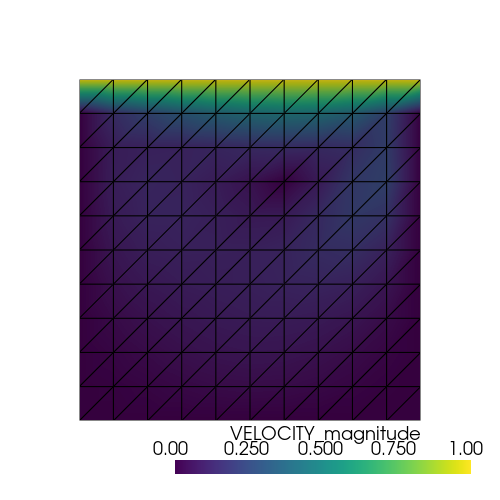

{
  "file": "/tmp/kratos-mcp-cavity-tq3a1n3h/vtk_output/FluidModelPart_0_30.vtk",
  "variable": "VELOCITY",
  "component": null,
  "camera": "xy",
  "warp_by": null,
  "warp_factor": 1.0,
  "window_size": [
    500,
    500
  ],
  "crop_bounds": null,
  "image_path": "/tmp/kratos-mcp-cavity-tq3a1n3h/vtk_output/FluidModelPart_0_30_VELOCITY.png",
  "data_range": [
    0.0,
    1.0
  ]
}


{'file': '/tmp/kratos-mcp-cavity-tq3a1n3h/vtk_output/FluidModelPart_0_30.vtk',
 'variable': 'VELOCITY',
 'component': None,
 'camera': 'xy',
 'warp_by': None,
 'warp_factor': 1.0,
 'window_size': [500, 500],
 'crop_bounds': None,
 'image_path': '/tmp/kratos-mcp-cavity-tq3a1n3h/vtk_output/FluidModelPart_0_30_VELOCITY.png',
 'data_range': [0.0, 1.0]}

In [13]:
await call("results_render", file=vtk_file, variable="VELOCITY",
           camera="xy", show_edges=True, window_size=[500, 500])

## 6. Animate the transient

Stitch the snapshots into a GIF: the vortex spins up from rest as the lid starts moving and settles to its steady shape.

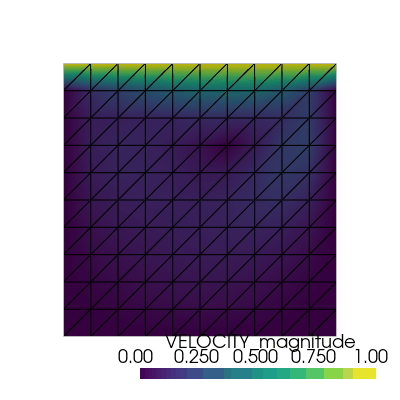

{
  "files": "/tmp/kratos-mcp-cavity-tq3a1n3h/vtk_output",
  "variable": "VELOCITY",
  "component": null,
  "camera": "xy",
  "warp_by": null,
  "warp_factor": 1.0,
  "window_size": [
    400,
    400
  ],
  "crop_bounds": null,
  "gif_path": "/tmp/kratos-mcp-cavity-tq3a1n3h/vtk_output/FluidModelPart_VELOCITY.gif",
  "num_frames": 3,
  "fps": 3,
  "data_range": [
    0.0,
    1.0
  ]
}


{'files': '/tmp/kratos-mcp-cavity-tq3a1n3h/vtk_output',
 'variable': 'VELOCITY',
 'component': None,
 'camera': 'xy',
 'warp_by': None,
 'warp_factor': 1.0,
 'window_size': [400, 400],
 'crop_bounds': None,
 'gif_path': '/tmp/kratos-mcp-cavity-tq3a1n3h/vtk_output/FluidModelPart_VELOCITY.gif',
 'num_frames': 3,
 'fps': 3,
 'data_range': [0.0, 1.0]}

In [14]:
await call("results_animate", files=str(workdir / "vtk_output"),
           variable="VELOCITY", camera="xy", fps=3, window_size=[400, 400])

## Cleanup\n\nClose the client session (which stops the server subprocess). The case directory is left on disk — open its `vtk_output/` in ParaView to inspect the raw results yourself.

In [15]:
_stop_event.set()      # wake the lifecycle task up ...
await _server_task     # ... and let it exit its own AsyncExitStack from the task that opened it
print("session closed, server subprocess terminated")
print("case directory left on disk:", workdir)

session closed, server subprocess terminated
case directory left on disk: /tmp/kratos-mcp-cavity-tq3a1n3h
